#Preprocessing


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/iscas89_project')
print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/iscas89_project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle, os

train    = pd.read_csv('data/processed/train.csv')
test     = pd.read_csv('data/processed/test.csv')
all_data = pd.read_csv('data/processed/all_circuits.csv')

FEATURES = ['gate', 'and', 'inv', 'nor', 'nand', 'or', 'dff', 'in', 'out']

def complexity_group(g):
    if g < 200:   return 'Small (<200)'
    elif g < 500: return 'Medium (200–500)'
    else:         return 'Large (>500)'

all_data['complexity'] = all_data['gate'].apply(complexity_group)
train['complexity']    = train['gate'].apply(complexity_group)
test['complexity']     = test['gate'].apply(complexity_group)
print("✓ Complexity groups assigned")
print(all_data[['circuit','gate','complexity']].to_string(index=False))


✓ Complexity groups assigned
circuit  gate       complexity
   S208    66     Small (<200)
   S298    75     Small (<200)
   S349   104     Small (<200)
   S386   118     Small (<200)
   S400   106     Small (<200)
   S420   160     Small (<200)
   S444   119     Small (<200)
   S713   139     Small (<200)
   S820   256 Medium (200–500)
   S838   288 Medium (200–500)
   S953   311 Medium (200–500)
  S1238   428 Medium (200–500)
  S1423   490 Medium (200–500)
  S1494   558     Large (>500)
  S5378  1004     Large (>500)
  S9234  2027     Large (>500)
 S15850  3448     Large (>500)
 S35932 12204     Large (>500)
 S38417  8709     Large (>500)
 S38584 11448     Large (>500)
   S344   101     Small (<200)
   S382    99     Small (<200)
   S641   107     Small (<200)
  S1488   550     Large (>500)
 S13207  2573     Large (>500)


In [ ]:
X_train_raw = train[FEATURES].values
y_train     = train['power'].values
X_test_raw  = test[FEATURES].values
y_test      = test['power'].values
X_all_raw   = all_data[FEATURES].values
y_all       = all_data['power'].values

scaler      = StandardScaler()
X_train     = scaler.fit_transform(X_train_raw)
X_test      = scaler.transform(X_test_raw)
X_all       = scaler.transform(X_all_raw)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("X_all   shape:", X_all.shape)
print()
print("y_train range:", y_train.min(), "—", y_train.max())
print("y_test  range:", y_test.min(),  "—", y_test.max())


X_train shape: (20, 9)
X_test  shape: (5, 9)
X_all   shape: (25, 9)

y_train range: 0.00698 — 1.87987
y_test  range: 0.01046 — 0.35


In [ ]:
os.makedirs('data/processed', exist_ok=True)

arrays = {
    'X_train': X_train, 'y_train': y_train,
    'X_test':  X_test,  'y_test':  y_test,
    'X_all':   X_all,   'y_all':   y_all,
}
with open('data/processed/arrays.pkl', 'wb') as f:
    pickle.dump(arrays, f)

with open('data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

all_data.to_csv('data/processed/all_circuits.csv', index=False)
print("✓ Arrays saved to data/processed/arrays.pkl")
print("✓ Scaler saved to data/processed/scaler.pkl")


✓ Arrays saved to data/processed/arrays.pkl
✓ Scaler saved to data/processed/scaler.pkl


/tmp/ipykernel_4412/125178455.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X_train_raw, labels=FEATURES)
/tmp/ipykernel_4412/125178455.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_train, labels=FEATURES)


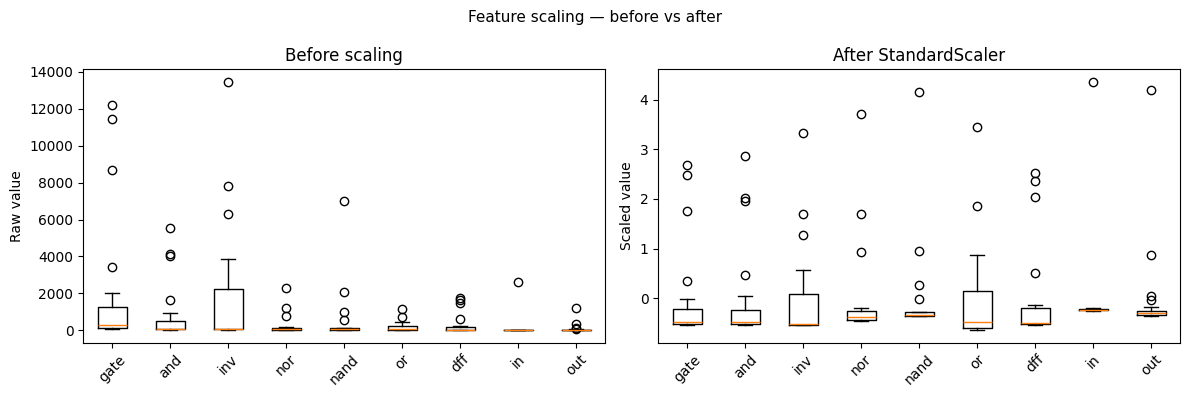

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(X_train_raw, labels=FEATURES)
axes[0].set_title('Before scaling')
axes[0].set_ylabel('Raw value')
axes[0].tick_params(axis='x', rotation=45)

axes[1].boxplot(X_train, labels=FEATURES)
axes[1].set_title('After StandardScaler')
axes[1].set_ylabel('Scaled value')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Feature scaling — before vs after', fontsize=11)
plt.tight_layout()
plt.savefig('results/figures/preprocessing_scaling.png', dpi=300, bbox_inches='tight')
plt.show()
